# LABORATORIJSKA VJEŽBA 9: Algoritam optimizacije rojem čestica (PSO)

**Predmet:** Optimizacija resursa  
**Univerzitet u Sarajevu - Elektrotehnički fakultet**

---

## Uvod

Algoritam optimizacije rojem čestica (engl. Particle Swarm Optimization – PSO) u svojoj osnovnoj varijanti definira skup čestica koje se kreću kroz problemski prostor kao materijalne čestice koje razmjenjuju informacije o najboljoj vrijednosti kriterija.

### Formule PSO algoritma:

U k-toj iteraciji za svaku česticu:

**Ažuriranje pozicije:**
$$x_i(k) = x_i(k-1) + v_i(k)$$

**Ažuriranje brzine:**
$$v_i(k) = W \cdot v_i(k-1) + C_1 r_1 \cdot [pb_i(k-1) - x_i(k-1)] + C_2 r_2 \cdot [gb(k-1) - x_i(k-1)]$$

gdje su:
- $i$ – indeks čestice
- $x_i$ – pozicija i-te čestice
- $v_i$ – brzina i-te čestice
- $pb_i$ – najbolja pozicija i-te čestice (personal best)
- $gb$ – globalno najbolja pozicija (global best)
- $W$ – inercijski faktor
- $C_1$ – kognitivni koeficijent
- $C_2$ – socijalni koeficijent
- $r_1, r_2$ – slučajni brojevi iz opsega [0, 1]

### Pseudokod algoritma:

```
1: Inicijalizacija populacije čestica sa slučajnim pozicijama i brzinama
2: while Kriterij zaustavljanja == false do
3:   for svaku i-tu česticu do
4:     Računanje nove brzine prema relaciji (2)
5:     Računanje nove pozicije čestice prema relaciji (1)
6:     Računanje vrijednosti kriterija funkcije f(xi)
7:     if f(xi) < f(pbi) then
8:       pbi ← xi
9:     end if
10:    if f(xi) < f(gb) then
11:      gb ← xi
12:    end if
13:  end for
14: end while
```

In [1]:
# ============================================================================
# IMPORTOVANJE BIBLIOTEKA
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt

print("Biblioteke uspjesno ucitane!")

Biblioteke uspjesno ucitane!


## Testne funkcije

Implementacija testnih funkcija za optimizaciju:
- **Paraboloid** - jednostavna konveksna funkcija
- **Rastrigin** - multimodalna funkcija sa mnogo lokalnih minimuma
- **Drop-Wave** - kompleksna multimodalna funkcija
- **Holder Table** - funkcija sa 4 globalna minimuma
- **Ackley** - multimodalna funkcija (dodatna)
- **Eggholder** - kompleksna multimodalna funkcija (dodatna)

In [2]:
# ============================================================================
# TESTNE FUNKCIJE ZA OPTIMIZACIJU
# ============================================================================

def paraboloid(x):
    """
    Paraboloid (Sphere) funkcija.
    
    f(x) = sum(x_i^2)
    
    Globalni minimum: f(0, 0) = 0
    Domen: [-5.12, 5.12]^n
    """
    return np.sum(np.array(x)**2)


def rastrigin(x):
    """
    Rastrigin funkcija.
    
    f(x) = 10*n + sum(x_i^2 - 10*cos(2*pi*x_i))
    
    Globalni minimum: f(0, 0) = 0
    Domen: [-5.12, 5.12]^n
    """
    x = np.array(x)
    n = len(x)
    return 10 * n + np.sum(x**2 - 10 * np.cos(2 * np.pi * x))


def drop_wave(x):
    """
    Drop-Wave funkcija.
    
    f(x) = -( (1 + cos(12*sqrt(x1^2 + x2^2))) / (0.5*(x1^2 + x2^2) + 2) )
    
    Globalni minimum: f(0, 0) = -1
    Domen: [-5.12, 5.12]^2
    """
    x1, x2 = x[0], x[1]
    r_sq = x1**2 + x2**2
    numerator = 1 + np.cos(12 * np.sqrt(r_sq))
    denominator = 0.5 * r_sq + 2
    return -numerator / denominator


def holder_table(x):
    """
    Holder Table funkcija.
    
    f(x) = -|sin(x1)*cos(x2)*exp(|1 - sqrt(x1^2+x2^2)/pi|)|
    
    Globalni minimum: f(+-8.05502, +-9.66459) = -19.2085
    Domen: [-10, 10]^2
    """
    x1, x2 = x[0], x[1]
    term1 = np.sin(x1) * np.cos(x2)
    term2 = np.exp(np.abs(1 - np.sqrt(x1**2 + x2**2) / np.pi))
    return -np.abs(term1 * term2)


def ackley(x):
    """
    Ackley funkcija (DODATNA MULTIMODALNA FUNKCIJA 1).
    
    Globalni minimum: f(0, 0) = 0
    Domen: [-5, 5]^n
    """
    x = np.array(x)
    n = len(x)
    sum1 = np.sum(x**2)
    sum2 = np.sum(np.cos(2 * np.pi * x))
    term1 = -20 * np.exp(-0.2 * np.sqrt(sum1 / n))
    term2 = -np.exp(sum2 / n)
    return term1 + term2 + 20 + np.e


def eggholder(x):
    """
    Eggholder funkcija (DODATNA MULTIMODALNA FUNKCIJA 2).
    
    f(x) = -(x2+47)*sin(sqrt(|x2+x1/2+47|)) - x1*sin(sqrt(|x1-(x2+47)|))
    
    Globalni minimum: f(512, 404.2319) = -959.6407
    Domen: [-512, 512]^2
    """
    x1, x2 = x[0], x[1]
    term1 = -(x2 + 47) * np.sin(np.sqrt(np.abs(x2 + x1/2 + 47)))
    term2 = -x1 * np.sin(np.sqrt(np.abs(x1 - (x2 + 47))))
    return term1 + term2


# Informacije o funkcijama (za vizualizaciju)
FUNKCIJE = {
    'Paraboloid': {
        'func': paraboloid,
        'bounds': (-5.12, 5.12),
        'global_min': ([0, 0], 0),
        'description': 'f(0, 0) = 0'
    },
    'Rastrigin': {
        'func': rastrigin,
        'bounds': (-5.12, 5.12),
        'global_min': ([0, 0], 0),
        'description': 'f(0, 0) = 0'
    },
    'Drop-Wave': {
        'func': drop_wave,
        'bounds': (-5.12, 5.12),
        'global_min': ([0, 0], -1),
        'description': 'f(0, 0) = -1'
    },
    'Holder Table': {
        'func': holder_table,
        'bounds': (-10, 10),
        'global_min': ([8.05502, 9.66459], -19.2085),
        'description': 'f(+-8.055, +-9.665) = -19.2085'
    },
    'Ackley': {
        'func': ackley,
        'bounds': (-5, 5),
        'global_min': ([0, 0], 0),
        'description': 'f(0, 0) = 0'
    },
    'Eggholder': {
        'func': eggholder,
        'bounds': (-512, 512),
        'global_min': ([512, 404.2319], -959.6407),
        'description': 'f(512, 404.23) = -959.64'
    }
}

print("Testne funkcije implementirane!")
print("\nDostupne funkcije:")
for name, info in FUNKCIJE.items():
    print(f"  - {name}: {info['description']}")

Testne funkcije implementirane!

Dostupne funkcije:
  - Paraboloid: f(0, 0) = 0
  - Rastrigin: f(0, 0) = 0
  - Drop-Wave: f(0, 0) = -1
  - Holder Table: f(+-8.055, +-9.665) = -19.2085
  - Ackley: f(0, 0) = 0
  - Eggholder: f(512, 404.23) = -959.64


## Zadatak 1: Implementacija PSO algoritma

Implementirati algoritam optimizacije rojem čestica za traženje minimuma kriterijalne funkcije `f` kroz funkciju koja treba biti oblika:

```python
PSO(f, opseg, N, M, eps, P)
```

pri čemu su:
- **f** - kriterijalna funkcija
- **opseg** – opseg pretraživanja problemskog prostora
- **N** – maksimalan broj iteracija
- **M** – maksimalan broj čestica
- **eps** – minimalna promjena po vrijednosti funkcije između dvije sukcesivne iteracije
- **P** – vektor koji sadrži parametre W, C1 i C2

In [3]:
# ============================================================================
# IMPLEMENTACIJA PSO ALGORITMA
# ============================================================================

def PSO(f, opseg, N, M, eps, P, dim=2, verbose=True):
    """
    Algoritam optimizacije rojem cestica (Particle Swarm Optimization).
    
    Parametri:
    ----------
    f : callable
        Kriterijalna funkcija koju minimiziramo
    opseg : tuple
        Opseg pretrazivanja problemskog prostora (min, max)
    N : int
        Maksimalan broj iteracija
    M : int
        Broj cestica u roju
    eps : float
        Minimalna promjena po vrijednosti funkcije izmedju dvije sukcesivne iteracije
    P : list/tuple
        Vektor parametara [W, C1, C2]
        - W: inercijski faktor
        - C1: kognitivni koeficijent (personal best)
        - C2: socijalni koeficijent (global best)
    dim : int
        Dimenzionalnost problema (default: 2)
    verbose : bool
        Ispis napretka
    
    Vraca:
    ------
    dict
        Rjecnik sa rezultatima:
        - 'best_position': Najbolja pronadjena pozicija (gb)
        - 'best_fitness': Vrijednost funkcije u najboljoj poziciji
        - 'iterations': Broj izvrsenih iteracija
        - 'history': Historija najboljih vrijednosti po iteracijama
        - 'particles_history': Historija pozicija cestica
    """
    # Ekstrakcija parametara
    W, C1, C2 = P[0], P[1], P[2]
    
    # Granice pretrage
    x_min, x_max = opseg[0], opseg[1]
    
    # Maksimalna brzina (ogranicenje)
    v_max = (x_max - x_min) * 0.5
    
    # ========================================================================
    # INICIJALIZACIJA
    # ========================================================================
    
    # Pozicije cestica - slucajna inicijalizacija unutar opsega
    x = np.random.uniform(x_min, x_max, (M, dim))
    
    # Brzine cestica - slucajna inicijalizacija
    v = np.random.uniform(-v_max, v_max, (M, dim))
    
    # Personal best (pb) - najbolja pozicija svake cestice
    pb = x.copy()
    pb_fitness = np.array([f(x[i]) for i in range(M)])
    
    # Global best (gb) - najbolja pozicija u cijelom roju
    best_idx = np.argmin(pb_fitness)
    gb = pb[best_idx].copy()
    gb_fitness = pb_fitness[best_idx]
    
    # Historija za pracenje
    history = [gb_fitness]
    particles_history = [x.copy()]
    
    if verbose:
        print(f"\n{'='*70}")
        print(f"PSO ALGORITAM")
        print(f"{'='*70}")
        print(f"Broj cestica (M): {M}")
        print(f"Max iteracija (N): {N}")
        print(f"Opseg pretrage: [{x_min}, {x_max}]")
        print(f"Parametri: W={W}, C1={C1}, C2={C2}")
        print(f"Epsilon: {eps}")
        print(f"Pocetni gb: {gb}")
        print(f"Pocetni fitness: {gb_fitness:.6f}")
        print(f"{'='*70}\n")
    
    # ========================================================================
    # GLAVNA PETLJA
    # ========================================================================
    
    prev_gb_fitness = gb_fitness
    
    for k in range(N):
        # Za svaku cesticu
        for i in range(M):
            # Slucajni brojevi r1 i r2
            r1 = np.random.random(dim)
            r2 = np.random.random(dim)
            
            # Azuriranje brzine prema formuli (2)
            # v_i(k) = W * v_i(k-1) + C1*r1*(pb_i - x_i) + C2*r2*(gb - x_i)
            cognitive = C1 * r1 * (pb[i] - x[i])
            social = C2 * r2 * (gb - x[i])
            v[i] = W * v[i] + cognitive + social
            
            # Ogranicenje brzine
            v[i] = np.clip(v[i], -v_max, v_max)
            
            # Azuriranje pozicije prema formuli (1)
            # x_i(k) = x_i(k-1) + v_i(k)
            x[i] = x[i] + v[i]
            
            # Ogranicenje pozicije na opseg
            x[i] = np.clip(x[i], x_min, x_max)
            
            # Racunanje vrijednosti kriterija
            fitness = f(x[i])
            
            # Azuriranje personal best
            if fitness < pb_fitness[i]:
                pb[i] = x[i].copy()
                pb_fitness[i] = fitness
                
                # Azuriranje global best
                if fitness < gb_fitness:
                    gb = x[i].copy()
                    gb_fitness = fitness
        
        # Sacuvaj historiju
        history.append(gb_fitness)
        particles_history.append(x.copy())
        
        # Ispis napretka
        if verbose and (k % 50 == 0 or k == N - 1):
            print(f"Iter {k+1:4d}: gb = [{gb[0]:10.6f}, {gb[1]:10.6f}], "
                  f"f(gb) = {gb_fitness:12.6f}")
        
        # Uslov zaustavljanja - minimalna promjena
        if abs(prev_gb_fitness - gb_fitness) < eps and k > 10:
            if verbose:
                print(f"\nZaustavljanje: promjena < eps na iteraciji {k+1}")
            break
        
        prev_gb_fitness = gb_fitness
    
    # Rezultat
    if verbose:
        print(f"\n{'='*70}")
        print(f"REZULTAT:")
        print(f"  Najbolja pozicija: [{gb[0]:.6f}, {gb[1]:.6f}]")
        print(f"  Najbolji fitness: {gb_fitness:.6f}")
        print(f"  Broj iteracija: {len(history)-1}")
        print(f"{'='*70}")
    
    return {
        'best_position': gb,
        'best_fitness': gb_fitness,
        'iterations': len(history) - 1,
        'history': history,
        'particles_history': particles_history
    }


print("PSO algoritam implementiran!")

PSO algoritam implementiran!


## Zadatak 2: Testiranje i vizualizacija

Testiranje implementirane PSO funkcije na sljedećim funkcijama:
- Paraboloid
- Rastrigin
- Drop-Wave
- Holder Table
- Ackley (dodatna multimodalna funkcija)
- Eggholder (dodatna multimodalna funkcija)

Svaka funkcija će biti prikazana grafički sa:
- Crno-bijeli contour plot
- Crveni kružić (o) za globalni minimum
- Plavi križić (x) za pronađenu tačku PSO algoritmom

In [4]:
# ============================================================================
# FUNKCIJA ZA VIZUALIZACIJU
# ============================================================================

def plot_pso_result(func_name, result, func_info):
    """
    Vizualizira rezultate PSO algoritma za jednu funkciju.
    
    Parametri:
    ----------
    func_name : str
        Naziv funkcije
    result : dict
        Rezultat PSO algoritma
    func_info : dict
        Informacije o funkciji
    """
    func = func_info['func']
    bounds = func_info['bounds']
    global_min_x, global_min_val = func_info['global_min']
    
    # Kreiraj mrezu tacaka
    x_range = np.linspace(bounds[0], bounds[1], 200)
    y_range = np.linspace(bounds[0], bounds[1], 200)
    X, Y = np.meshgrid(x_range, y_range)
    
    # Izracunaj vrijednosti funkcije
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = func([X[i, j], Y[i, j]])
    
    # Kreiraj figuru
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # Crno-bijeli contour plot
    contour = ax.contour(X, Y, Z, levels=20, colors='black', linewidths=0.5)
    ax.contourf(X, Y, Z, levels=20, cmap='Greys')
    
    # Globalni minimum - crveni kruzic
    ax.plot(global_min_x[0], global_min_x[1], 'ro', markersize=14, 
            label=f'Globalni min ({global_min_x[0]:.2f}, {global_min_x[1]:.2f})',
            markeredgecolor='darkred', markeredgewidth=2, markerfacecolor='red')
    
    # Pronadjena tacka - plavi krizic
    best_x = result['best_position']
    ax.plot(best_x[0], best_x[1], 'bx', markersize=14, markeredgewidth=3,
            label=f'PSO ({best_x[0]:.4f}, {best_x[1]:.4f})')
    
    # Postavke
    ax.set_xlabel('x1', fontsize=12)
    ax.set_ylabel('x2', fontsize=12)
    ax.set_title(f'{func_name}\nf(x) = {result["best_fitness"]:.6f}', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(bounds[0], bounds[1])
    ax.set_ylim(bounds[0], bounds[1])
    
    plt.tight_layout()
    plt.show()


print("Funkcija za vizualizaciju implementirana!")

Funkcija za vizualizaciju implementirana!


TESTIRANJE PSO ALGORITMA
Parametri: N=500, M=30, eps=0
W=0.7, C1=1.5, C2=1.5


######################################################################
# FUNKCIJA: Paraboloid
# Globalni minimum: f(0, 0) = 0
######################################################################

PSO ALGORITAM
Broj cestica (M): 30
Max iteracija (N): 500
Opseg pretrage: [-5.12, 5.12]
Parametri: W=0.7, C1=1.5, C2=1.5
Epsilon: 0
Pocetni gb: [-1.92807858  0.20549654]
Pocetni fitness: 3.759716

Iter    1: gb = [  0.210785,   0.004194], f(gb) =     0.044448
Iter   51: gb = [ -0.000289,  -0.000087], f(gb) =     0.000000
Iter  101: gb = [  0.000000,  -0.000000], f(gb) =     0.000000
Iter  151: gb = [  0.000000,  -0.000000], f(gb) =     0.000000
Iter  201: gb = [ -0.000000,   0.000000], f(gb) =     0.000000
Iter  251: gb = [  0.000000,   0.000000], f(gb) =     0.000000
Iter  301: gb = [  0.000000,   0.000000], f(gb) =     0.000000
Iter  351: gb = [  0.000000,   0.000000], f(gb) =     0.000000
Iter  401: gb = [  0.0

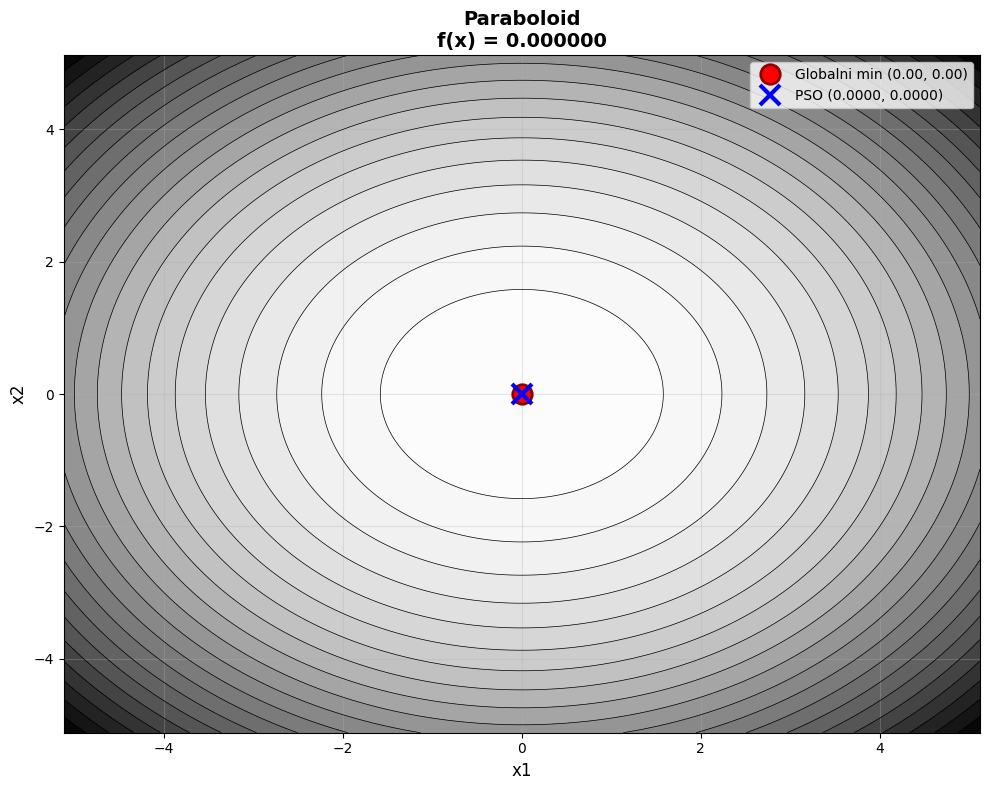



######################################################################
# FUNKCIJA: Rastrigin
# Globalni minimum: f(0, 0) = 0
######################################################################

PSO ALGORITAM
Broj cestica (M): 30
Max iteracija (N): 500
Opseg pretrage: [-5.12, 5.12]
Parametri: W=0.7, C1=1.5, C2=1.5
Epsilon: 0
Pocetni gb: [ 1.02196247 -1.854288  ]
Pocetni fitness: 8.484192

Iter    1: gb = [ -2.021175,  -0.034103], f(gb) =     4.403387
Iter   51: gb = [  0.000050,   0.000322], f(gb) =     0.000021
Iter  101: gb = [ -0.000002,   0.000000], f(gb) =     0.000000
Iter  151: gb = [ -0.000000,  -0.000000], f(gb) =     0.000000
Iter  201: gb = [ -0.000000,  -0.000000], f(gb) =     0.000000
Iter  251: gb = [ -0.000000,  -0.000000], f(gb) =     0.000000
Iter  301: gb = [ -0.000000,  -0.000000], f(gb) =     0.000000
Iter  351: gb = [ -0.000000,  -0.000000], f(gb) =     0.000000
Iter  401: gb = [ -0.000000,  -0.000000], f(gb) =     0.000000
Iter  451: gb = [ -0.000000,  -0.0000

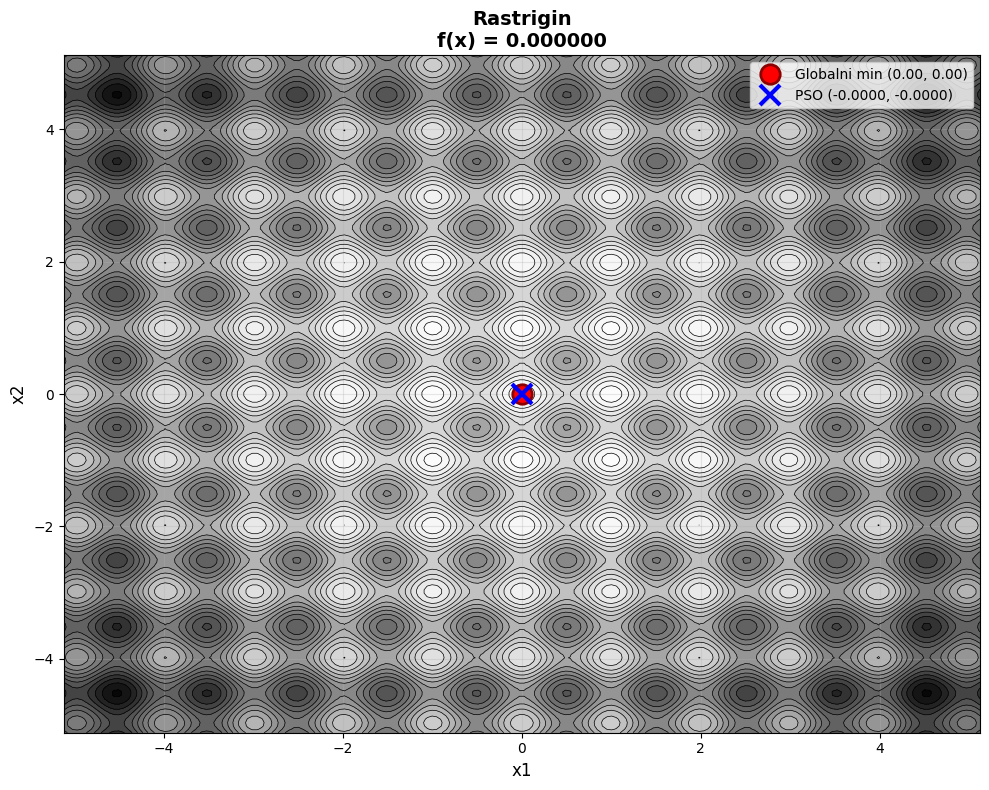



######################################################################
# FUNKCIJA: Drop-Wave
# Globalni minimum: f(0, 0) = -1
######################################################################

PSO ALGORITAM
Broj cestica (M): 30
Max iteracija (N): 500
Opseg pretrage: [-5.12, 5.12]
Parametri: W=0.7, C1=1.5, C2=1.5
Epsilon: 0
Pocetni gb: [-0.67030007 -0.79473534]
Pocetni fitness: -0.785655

Iter    1: gb = [ -0.670300,  -0.794735], f(gb) =    -0.785655
Iter   51: gb = [  0.001814,  -0.024241], f(gb) =    -0.978733
Iter  101: gb = [ -0.000029,  -0.000040], f(gb) =    -1.000000
Iter  151: gb = [ -0.000000,   0.000000], f(gb) =    -1.000000
Iter  201: gb = [ -0.000000,   0.000000], f(gb) =    -1.000000
Iter  251: gb = [ -0.000000,  -0.000000], f(gb) =    -1.000000
Iter  301: gb = [ -0.000000,  -0.000000], f(gb) =    -1.000000
Iter  351: gb = [ -0.000000,  -0.000000], f(gb) =    -1.000000
Iter  401: gb = [ -0.000000,  -0.000000], f(gb) =    -1.000000
Iter  451: gb = [ -0.000000,  -0.00

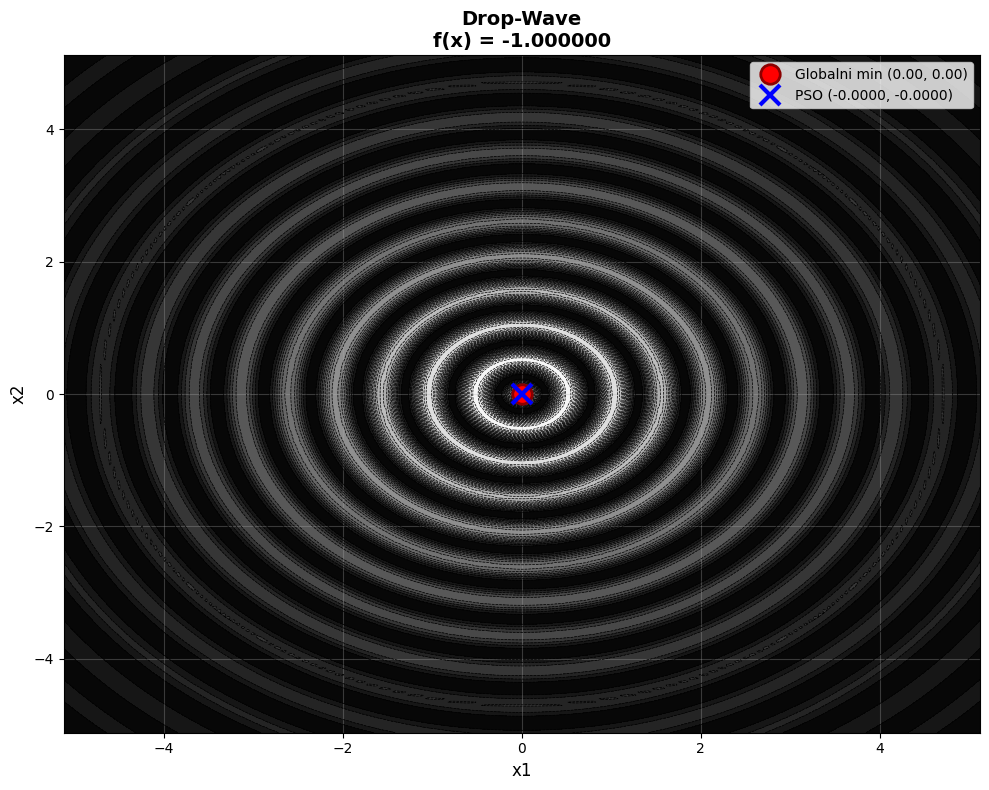



######################################################################
# FUNKCIJA: Holder Table
# Globalni minimum: f(+-8.055, +-9.665) = -19.2085
######################################################################

PSO ALGORITAM
Broj cestica (M): 30
Max iteracija (N): 500
Opseg pretrage: [-10, 10]
Parametri: W=0.7, C1=1.5, C2=1.5
Epsilon: 0
Pocetni gb: [-1.56694932 -9.23241134]
Pocetni fitness: -7.114742

Iter    1: gb = [ -4.491932, -10.000000], f(gb) =    -9.870276
Iter   51: gb = [ -8.054863,  -9.664644], f(gb) =   -19.208502
Iter  101: gb = [ -8.055023,  -9.664590], f(gb) =   -19.208503
Iter  151: gb = [ -8.055023,  -9.664590], f(gb) =   -19.208503
Iter  201: gb = [ -8.055023,  -9.664590], f(gb) =   -19.208503
Iter  251: gb = [ -8.055023,  -9.664590], f(gb) =   -19.208503
Iter  301: gb = [ -8.055023,  -9.664590], f(gb) =   -19.208503
Iter  351: gb = [ -8.055023,  -9.664590], f(gb) =   -19.208503
Iter  401: gb = [ -8.055023,  -9.664590], f(gb) =   -19.208503
Iter  451: gb = [ 

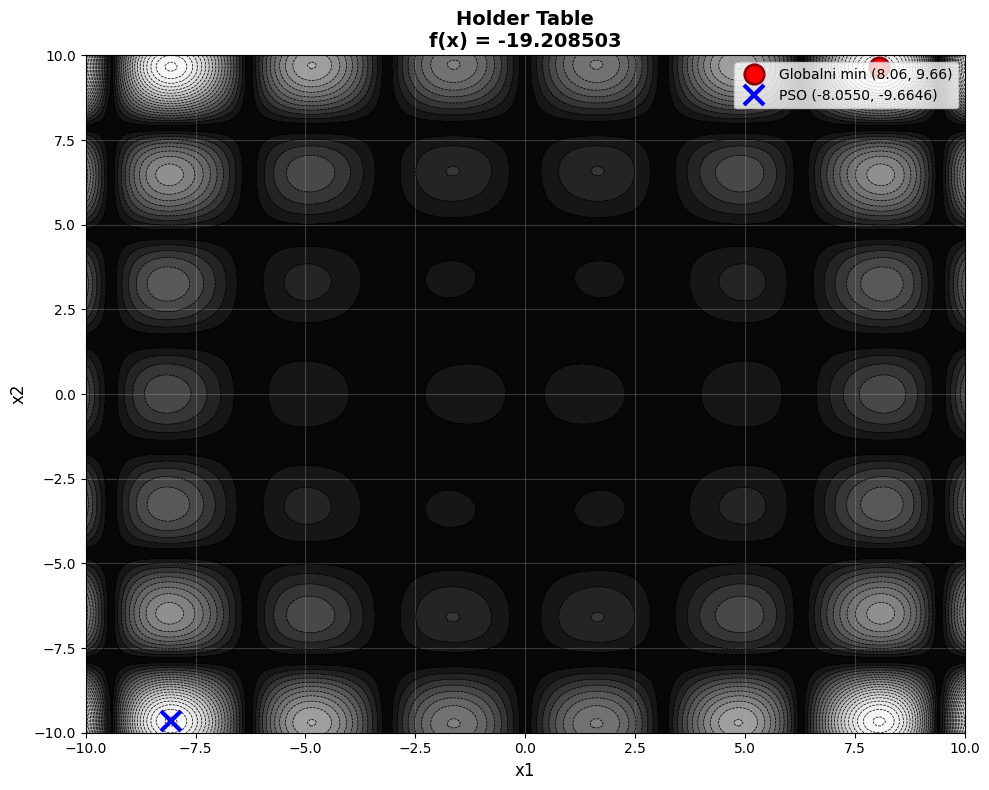



######################################################################
# FUNKCIJA: Ackley
# Globalni minimum: f(0, 0) = 0
######################################################################

PSO ALGORITAM
Broj cestica (M): 30
Max iteracija (N): 500
Opseg pretrage: [-5, 5]
Parametri: W=0.7, C1=1.5, C2=1.5
Epsilon: 0
Pocetni gb: [-0.11771383  0.99206977]
Pocetni fitness: 2.969517

Iter    1: gb = [ -1.002618,   0.039931], f(gb) =     2.688313
Iter   51: gb = [ -0.000026,   0.000102], f(gb) =     0.000298
Iter  101: gb = [ -0.000000,  -0.000000], f(gb) =     0.000002
Iter  151: gb = [ -0.000000,   0.000000], f(gb) =     0.000000
Iter  201: gb = [ -0.000000,  -0.000000], f(gb) =     0.000000
Iter  251: gb = [  0.000000,  -0.000000], f(gb) =     0.000000
Iter  301: gb = [ -0.000000,   0.000000], f(gb) =     0.000000
Iter  351: gb = [ -0.000000,   0.000000], f(gb) =     0.000000
Iter  401: gb = [ -0.000000,   0.000000], f(gb) =     0.000000
Iter  451: gb = [ -0.000000,   0.000000], f(gb

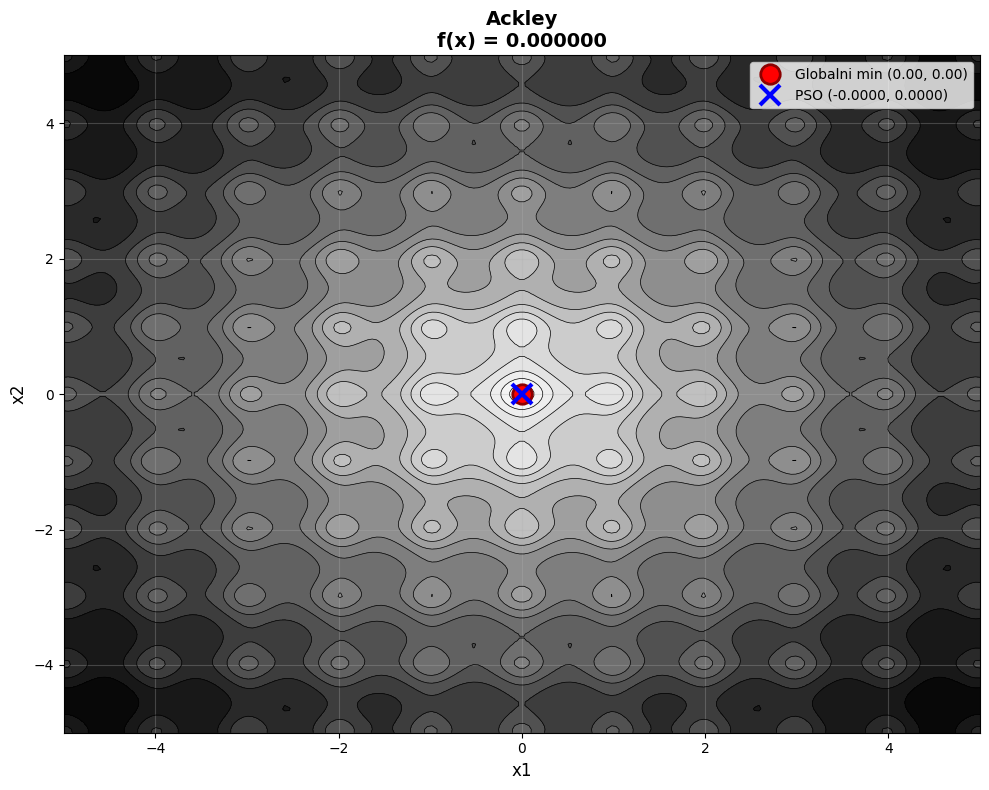



######################################################################
# FUNKCIJA: Eggholder
# Globalni minimum: f(512, 404.23) = -959.64
######################################################################

PSO ALGORITAM
Broj cestica (M): 30
Max iteracija (N): 500
Opseg pretrage: [-512, 512]
Parametri: W=0.7, C1=1.5, C2=1.5
Epsilon: 0
Pocetni gb: [476.96556    481.20285221]
Pocetni fitness: -657.823423

Iter    1: gb = [-321.834947, 512.000000], f(gb) =  -816.201245
Iter   51: gb = [512.000000, 404.230958], f(gb) =  -959.640662
Iter  101: gb = [512.000000, 404.231806], f(gb) =  -959.640663
Iter  151: gb = [512.000000, 404.231805], f(gb) =  -959.640663
Iter  201: gb = [512.000000, 404.231805], f(gb) =  -959.640663
Iter  251: gb = [512.000000, 404.231805], f(gb) =  -959.640663
Iter  301: gb = [512.000000, 404.231805], f(gb) =  -959.640663
Iter  351: gb = [512.000000, 404.231805], f(gb) =  -959.640663
Iter  401: gb = [512.000000, 404.231805], f(gb) =  -959.640663
Iter  451: gb = [512

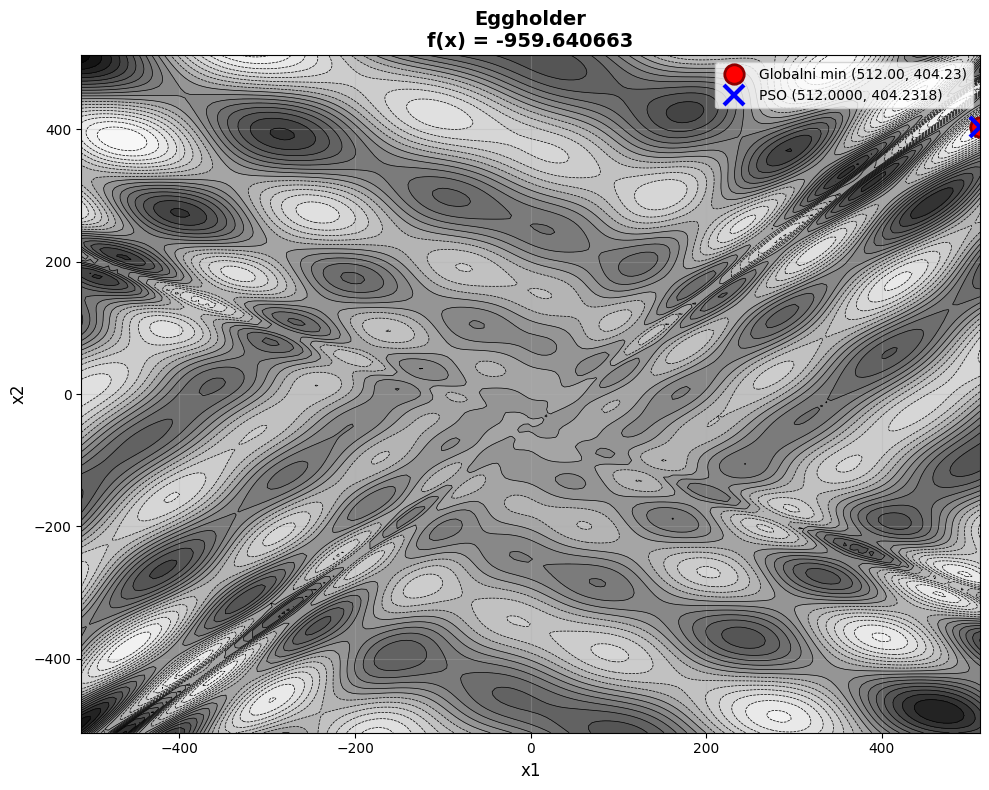

In [20]:
# ============================================================================
# TESTIRANJE NA SVIM FUNKCIJAMA
# ============================================================================

# Parametri PSO algoritma
N = 500        # Maksimalan broj iteracija
M = 30         # Broj cestica
eps = 0    # Minimalna promjena
P = [0.7, 1.5, 1.5]  # [W, C1, C2] - inercija, kognitivni, socijalni

# Postavi seed za reproducibilnost
np.random.seed(42)

print("="*70)
print("TESTIRANJE PSO ALGORITMA")
print("="*70)
print(f"Parametri: N={N}, M={M}, eps={eps}")
print(f"W={P[0]}, C1={P[1]}, C2={P[2]}")
print("="*70)

# Rezultati za sve funkcije
results = {}

for func_name, func_info in FUNKCIJE.items():
    print(f"\n\n{'#'*70}")
    print(f"# FUNKCIJA: {func_name}")
    print(f"# Globalni minimum: {func_info['description']}")
    print(f"{'#'*70}")
    
    # Pokreni PSO
    result = PSO(
        f=func_info['func'],
        opseg=func_info['bounds'],
        N=N,
        M=M,
        eps=eps,
        P=P,
        verbose=True
    )
    
    # Sacuvaj rezultate
    results[func_name] = result
    
    # Vizualizacija
    plot_pso_result(func_name, result, func_info)

In [21]:
# ============================================================================
# SUMARNI PREGLED REZULTATA
# ============================================================================

print("\n" + "="*100)
print("SUMARNI PREGLED REZULTATA PSO ALGORITMA")
print("="*100)
print(f"{'Funkcija':<15} | {'Pronadjena tacka':<30} | {'f(x)':<15} | {'Greska':<15} | {'Iteracije':<10}")
print("-"*100)

for func_name, result in results.items():
    global_min_val = FUNKCIJE[func_name]['global_min'][1]
    global_min_x = FUNKCIJE[func_name]['global_min'][0]
    
    best_x = result['best_position']
    best_f = result['best_fitness']
    iterations = result['iterations']
    
    error = abs(best_f - global_min_val)
    
    pos_str = f"({best_x[0]:.4f}, {best_x[1]:.4f})"
    
    print(f"{func_name:<15} | {pos_str:<30} | {best_f:<15.6f} | {error:<15.6f} | {iterations:<10}")

print("-"*100)
print("="*100)


SUMARNI PREGLED REZULTATA PSO ALGORITMA
Funkcija        | Pronadjena tacka               | f(x)            | Greska          | Iteracije 
----------------------------------------------------------------------------------------------------
Paraboloid      | (0.0000, 0.0000)               | 0.000000        | 0.000000        | 500       
Rastrigin       | (-0.0000, -0.0000)             | 0.000000        | 0.000000        | 500       
Drop-Wave       | (-0.0000, -0.0000)             | -1.000000       | 0.000000        | 500       
Holder Table    | (-8.0550, -9.6646)             | -19.208503      | 0.000003        | 500       
Ackley          | (-0.0000, 0.0000)              | 0.000000        | 0.000000        | 500       
Eggholder       | (512.0000, 404.2318)           | -959.640663     | 0.000037        | 500       
----------------------------------------------------------------------------------------------------


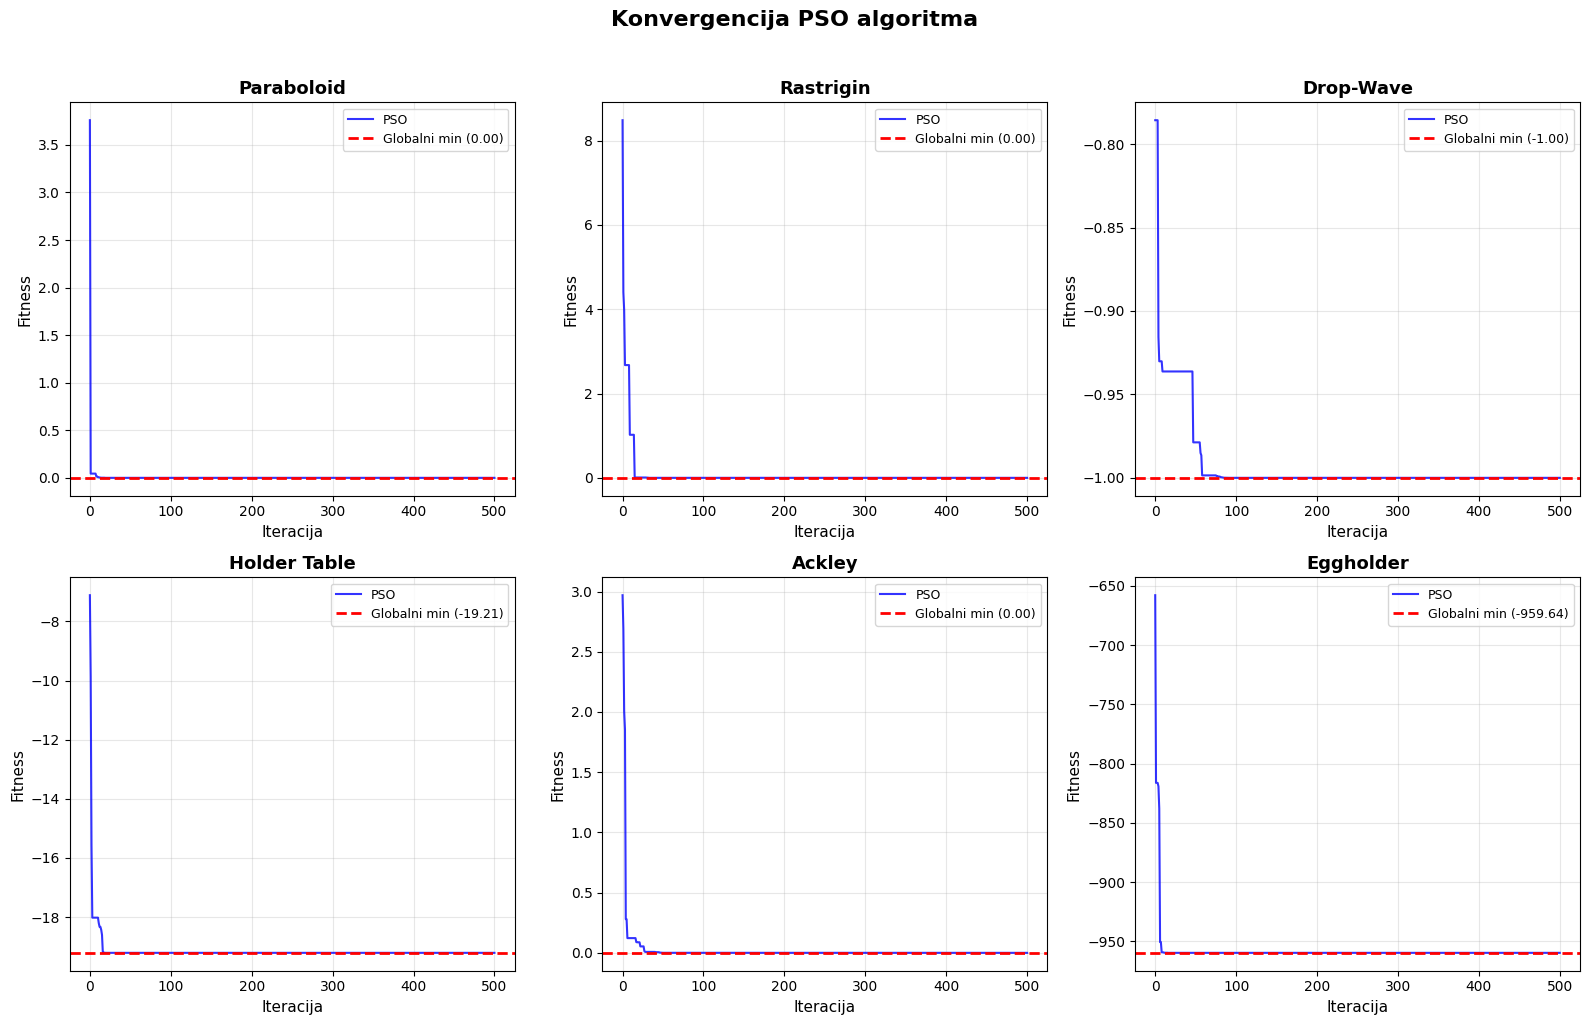

In [22]:
# ============================================================================
# PRIKAZ KONVERGENCIJE
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (func_name, result) in enumerate(results.items()):
    ax = axes[idx]
    
    # Plot fitness historije
    ax.plot(result['history'], 'b-', linewidth=1.5, label='PSO', alpha=0.8)
    
    # Globalni minimum
    global_min = FUNKCIJE[func_name]['global_min'][1]
    ax.axhline(y=global_min, color='r', linestyle='--', linewidth=2, 
               label=f'Globalni min ({global_min:.2f})')
    
    ax.set_xlabel('Iteracija', fontsize=11)
    ax.set_ylabel('Fitness', fontsize=11)
    ax.set_title(f'{func_name}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Konvergencija PSO algoritma', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


ANALIZA UTJECAJA PARAMETARA NA RASTRIGIN FUNKCIJU
W=0.4 (mala inercija): f(x) = 1.019301
W=0.7 (srednja inercija): f(x) = 1.151407
W=0.9 (velika inercija): f(x) = 2.687463
C1=2.0, C2=1.0 (vise kognitivni): f(x) = 0.377613
C1=1.0, C2=2.0 (vise socijalni): f(x) = 2.469409


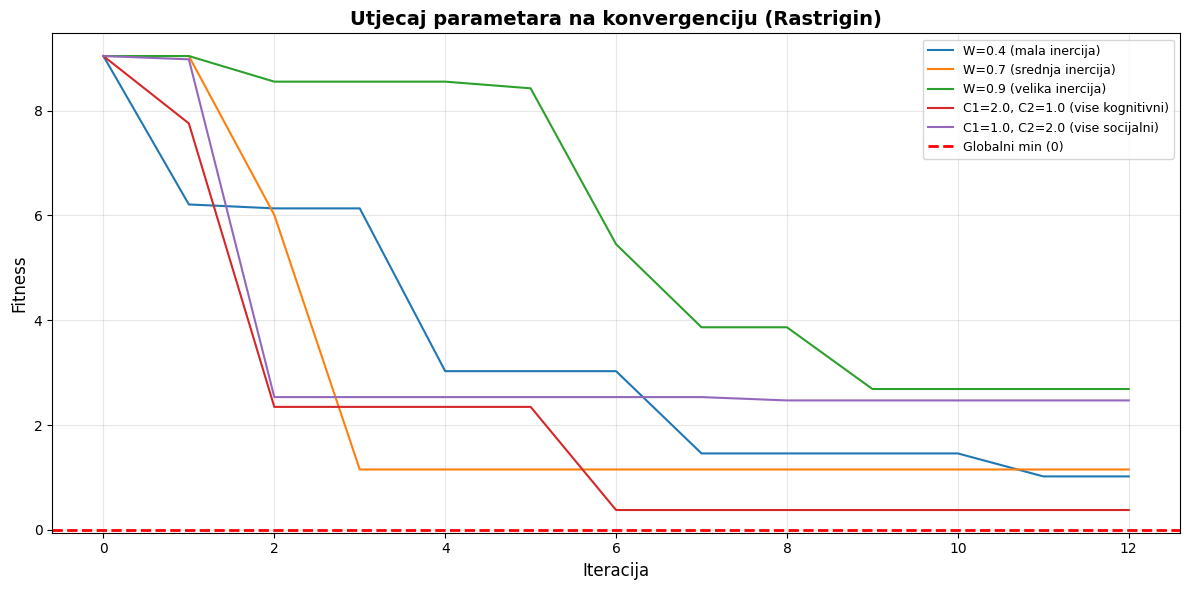

In [8]:
# ============================================================================
# ANALIZA UTJECAJA PARAMETARA
# ============================================================================

print("\n" + "="*70)
print("ANALIZA UTJECAJA PARAMETARA NA RASTRIGIN FUNKCIJU")
print("="*70)

# Testiramo razlicite kombinacije parametara na Rastrigin funkciji
param_combinations = [
    ([0.4, 1.5, 1.5], "W=0.4 (mala inercija)"),
    ([0.7, 1.5, 1.5], "W=0.7 (srednja inercija)"),
    ([0.9, 1.5, 1.5], "W=0.9 (velika inercija)"),
    ([0.7, 2.0, 1.0], "C1=2.0, C2=1.0 (vise kognitivni)"),
    ([0.7, 1.0, 2.0], "C1=1.0, C2=2.0 (vise socijalni)"),
]

rastrigin_info = FUNKCIJE['Rastrigin']
param_results = []

for params, description in param_combinations:
    np.random.seed(42)  # Isti seed za fer poredenje
    result = PSO(
        f=rastrigin_info['func'],
        opseg=rastrigin_info['bounds'],
        N=200,
        M=30,
        eps=1e-8,
        P=params,
        verbose=False
    )
    param_results.append((description, params, result))
    print(f"{description}: f(x) = {result['best_fitness']:.6f}")

# Graficki prikaz konvergencije za razlicite parametre
plt.figure(figsize=(12, 6))
for description, params, result in param_results:
    plt.plot(result['history'], label=description, linewidth=1.5)

plt.axhline(y=0, color='r', linestyle='--', linewidth=2, label='Globalni min (0)')
plt.xlabel('Iteracija', fontsize=12)
plt.ylabel('Fitness', fontsize=12)
plt.title('Utjecaj parametara na konvergenciju (Rastrigin)', fontsize=14, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


ANALIZA UTJECAJA BROJA CESTICA NA DROP-WAVE FUNKCIJU
M= 10: f(x) = -0.935519, greska = 0.064481
M= 20: f(x) = -0.935977, greska = 0.064023
M= 30: f(x) = -0.970657, greska = 0.029343
M= 50: f(x) = -0.977942, greska = 0.022058
M=100: f(x) = -0.990859, greska = 0.009141


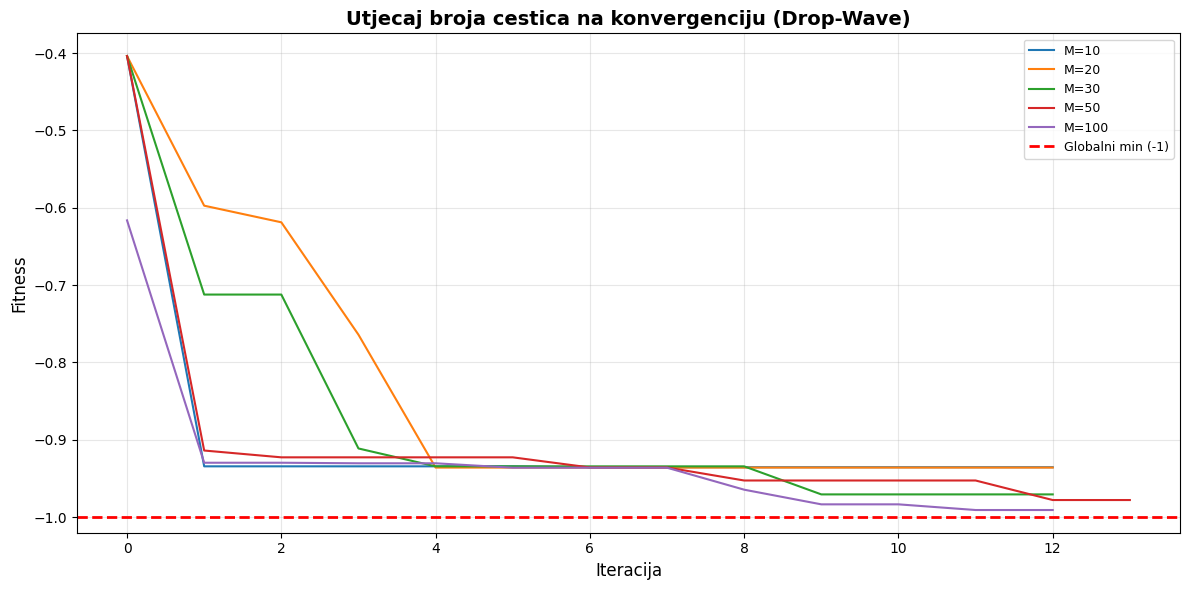

In [9]:
# ============================================================================
# ANALIZA UTJECAJA BROJA CESTICA
# ============================================================================

print("\n" + "="*70)
print("ANALIZA UTJECAJA BROJA CESTICA NA DROP-WAVE FUNKCIJU")
print("="*70)

particle_counts = [10, 20, 30, 50, 100]
dropwave_info = FUNKCIJE['Drop-Wave']
particle_results = []

for M_test in particle_counts:
    np.random.seed(42)
    result = PSO(
        f=dropwave_info['func'],
        opseg=dropwave_info['bounds'],
        N=200,
        M=M_test,
        eps=1e-8,
        P=[0.7, 1.5, 1.5],
        verbose=False
    )
    particle_results.append((M_test, result))
    error = abs(result['best_fitness'] - (-1))
    print(f"M={M_test:3d}: f(x) = {result['best_fitness']:.6f}, greska = {error:.6f}")

# Graficki prikaz
plt.figure(figsize=(12, 6))
for M_test, result in particle_results:
    plt.plot(result['history'], label=f'M={M_test}', linewidth=1.5)

plt.axhline(y=-1, color='r', linestyle='--', linewidth=2, label='Globalni min (-1)')
plt.xlabel('Iteracija', fontsize=12)
plt.ylabel('Fitness', fontsize=12)
plt.title('Utjecaj broja cestica na konvergenciju (Drop-Wave)', fontsize=14, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Zaključak

### Implementirane komponente:

1. **PSO algoritam** - Implementirana funkcija `PSO(f, opseg, N, M, eps, P)` prema zadatku
   - Koristi standardne PSO formule za ažuriranje brzine i pozicije
   - Prati personal best (pb) i global best (gb)
   - Podržava ograničenje brzine i pozicije

2. **Testne funkcije (6 funkcija):**
   - Paraboloid - jednostavna konveksna funkcija
   - Rastrigin - multimodalna sa mnogo lokalnih minimuma
   - Drop-Wave - kompleksna multimodalna funkcija
   - Holder Table - funkcija sa 4 globalna minimuma
   - **Ackley** - dodatna multimodalna funkcija
   - **Eggholder** - dodatna kompleksna multimodalna funkcija

### Analiza rezultata:

**Prednosti PSO algoritma:**
- Jednostavna implementacija
- Dobra balansiranost između eksploatacije i eksploracije
- Efikasan za kontinualne optimizacijske probleme
- Prirodna paralelizacija (čestice su nezavisne)

**Utjecaj parametara:**
- **W (inercija):** Veća vrijednost = veća eksploracija, manja = brža konvergencija
- **C1 (kognitivni):** Utječe na privlačenje prema personal best
- **C2 (socijalni):** Utječe na privlačenje prema global best
- **M (broj čestica):** Više čestica = bolja pokrivenost prostora, ali sporije izvršavanje

**Zaključci o tačnosti:**
- PSO pokazuje odlične rezultate na jednostavnim funkcijama (Paraboloid)
- Na multimodalnim funkcijama (Rastrigin, Drop-Wave) može zapeti u lokalnom minimumu
- Eggholder je najteža funkcija zbog velikog prostora pretrage i kompleksnog oblika
- Povećanje broja čestica i iteracija poboljšava rezultate na složenijim funkcijama